In [ ]:
%load_ext autoreload
%autoreload 2
%env CUDA_VISIBLE_DEVICES=1

import numpy as np
import sys
import os
import matplotlib.pyplot as plt
import vis_utils

from utils.utils import get_path
from utils.io_utils import load_multiple_res
from utils.toydata_utils import get_toy_data
from utils.fig_utils import dataset_to_print, plot_dgm_loops, dist_to_print
from utils.pd_utils import sort_cycle

from vis_utils.loaders import load_dataset
from vis_utils.plot import plot_scatter
from vis_utils.utils import load_dict, save_dict
from vis_utils.tsne_wrapper import TSNEwrapper
from openTSNE.affinity import Affinities

import umap
from ripser import Rips
from ripser.ripser import get_greedy_perm

from mpl_toolkits.axes_grid1 import make_axes_locatable

from matplotlib import collections  as mc
from matplotlib.colors import Normalize
import matplotlib.cm

from openTSNE.nearest_neighbors import PrecomputedNeighbors
from openTSNE.affinity import PerplexityBasedNN

from vis_utils.utils import kNN_graph, kNN_dists
from scipy.spatial.distance import pdist, squareform
import glasbey
import scipy.sparse
import networkx as nx

from sklearn.decomposition import PCA

from persim import plot_diagrams
from utils.pd_utils import get_life_times
import pandas as pd

from vis_utils.rnaseqTools import geneSelection, sparseload
import pickle
import torch
import urllib.request
import requests
 
from scipy.linalg import orthogonal_procrustes
from scipy.spatial import procrustes

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
env: CUDA_VISIBLE_DEVICES=1


<h4 style="background-color: yellow; padding: 5px;">

here i do procrustes alignation, which is to rotate the embedding of both cell groups(orange & purple) in yao's 10x female  dataset, so that the loops passing similar cell clusters would roughly appear at a similar position as yao's 10x male dataset. 

Also see "procrutes.ipynb" where I also rotate other dataset. 

</h4>

In [1293]:
root_path = get_path("data")
fig_path = get_path("figures")
# seeds = [0, 1, 2]
seeds = [0]
k = 15

style_file = "utils.style"
plt.style.use(style_file)

distances = {
    "euclidean": [{}],
}

# ------------------ 10x female ----------------------------------

# load data

note that the last element is absent, idx = 109, color is black(if nothing goes wrong...)

In [1686]:
n_epochs = 500
n_early_epochs = 250
perplexity = None    
rescale_tsne = True
seed = 0
k = 15
file_name = os.path.join(root_path,
                         "yao_10x_male",
                         f"tsne_bin_k_{k}_n_epochs_{n_epochs}_n_early_epochs_{n_early_epochs}_seed_{seed}_init_pca_rescale_{rescale_tsne}.pkl")
tsne_data = load_dict(file_name)
embd_10x_male = tsne_data["embds"][-1]


In [1305]:
file_name = os.path.join(root_path,
                         "yao_10x_female",
                         f"tsne_bin_k_{k}_n_epochs_{n_epochs}_n_early_epochs_{n_early_epochs}_seed_{seed}_init_pca_rescale_{rescale_tsne}.pkl")
tsne_data = load_dict(file_name)
embd_10x_female = tsne_data["embds"][-1]


In [1297]:

_,_,_,_,d_10x_male = load_dataset(root_path, "yao_10x_male", k=15, seed=0)
_,_,_,_, d_10x_female = load_dataset(root_path, "yao_10x_female", k=15, seed=0)


# making mask for figure

In [1688]:
idx_orange_10x_fig = [i for i, cluster in enumerate(d_10x_male["clusterNames"]) 
              if "_Sst" in cluster or "_Pvalb" in cluster]
mask_orange_10x_fig = [idx in idx_orange_10x_fig for idx in d_10x_male['clusters']]

In [1687]:
idx_purple_10x_fig = [i for i, cluster in enumerate(d_10x_male["clusterNames"]) 
              if "_Lamp5" in cluster and "Lhx6" not in cluster or "_Vip" in cluster or "_Sncg" in cluster or "_Pax6" in cluster or "_Ntng1" in cluster]
mask_purple_10x_fig = [idx in idx_purple_10x_fig for idx in d_10x_male['clusters']]


In [1300]:
idx_orange_10x_female_fig = [i for i, cluster in enumerate(d_10x_female["clusterNames"]) 
              if "_Sst" in cluster or "_Pvalb" in cluster]
mask_orange_10x_female_fig = [idx in idx_orange_10x_female_fig for idx in d_10x_female['clusters']]

In [1301]:
idx_purple_10x_female_fig = [i for i, cluster in enumerate(d_10x_female["clusterNames"]) 
              if "_Lamp5" in cluster and "Lhx6" not in cluster or "_Vip" in cluster or "_Sncg" in cluster or "_Pax6" in cluster or "_Ntng1" in cluster]
mask_purple_10x_female_fig = [idx in idx_purple_10x_female_fig for idx in d_10x_female['clusters']]

In [1302]:
sum(mask_purple_10x_female_fig)

32750

In [1303]:
sum(mask_orange_10x_female_fig)

25000

# procrustes

In [1306]:
clusters_mean_10x_female = []
clusters_size_10x_female_purple = []
for cluster in idx_purple_10x_fig:
    cluster_idx = np.where(d_10x_female['clusters'] == cluster)[0]
    cluster_pos = embd_10x_female[cluster_idx]
    cluster_mean = np.mean(cluster_pos, axis=0)
    clusters_mean_10x_female.append(cluster_mean)
    clusters_size_10x_female_purple.append(len(cluster_idx))
clusters_mean_10x_female_purple = np.vstack(clusters_mean_10x_female)
weight_10x_female_purple = np.vstack(clusters_size_10x_female_purple) / np.sum(clusters_size_10x_female_purple)

In [1307]:
sorted_10x_female_purple = [index for index, value in sorted(enumerate(weight_10x_female_purple), key=lambda x: x[1], reverse=True)]
cumsum_10x_female_purple = np.cumsum(weight_10x_female_purple[sorted_10x_female_purple])
num_10x_female_purple = len(cumsum_10x_female_purple[cumsum_10x_female_purple<0.6])
partial_10x_female_purple = sorted_10x_female_purple[:num_10x_female_purple]


In [1308]:
sum(clusters_size_10x_female_purple)

32750

In [1309]:
clusters_mean_10x_female = []
clusters_size_10x_female_orange = []
for cluster in idx_orange_10x_fig:
    cluster_idx = np.where(d_10x_female['clusters'] == cluster)[0]
    cluster_pos = embd_10x_female[cluster_idx]
    cluster_mean = np.mean(cluster_pos, axis=0)
    clusters_mean_10x_female.append(cluster_mean)
    clusters_size_10x_female_orange.append(len(cluster_idx))
clusters_mean_10x_female_orange = np.vstack(clusters_mean_10x_female)
weight_10x_female_orange = np.vstack(clusters_size_10x_female_orange) / np.sum(clusters_size_10x_female_orange)


In [1310]:
sorted_10x_female_orange = [index for index, value in sorted(enumerate(weight_10x_female_orange), key=lambda x: x[1], reverse=True)]
cumsum_10x_female_orange = np.cumsum(weight_10x_female_orange[sorted_10x_female_orange])
num_10x_female_orange = len(cumsum_10x_female_orange[cumsum_10x_female_orange<0.6])
partial_10x_female_orange = sorted_10x_female_orange[:num_10x_female_orange]

In [1311]:
sum(clusters_size_10x_female_orange)

25000

In [1312]:
clusters_mean_10x = []
clusters_size_10x = []
for cluster in idx_purple_10x_fig + idx_orange_10x_fig:
    cluster_idx = np.where(d_10x_male['clusters'] == cluster)[0]
    cluster_pos = embd_10x_male[cluster_idx]
    cluster_mean = np.mean(cluster_pos, axis=0)
    clusters_mean_10x.append(cluster_mean)
    clusters_size_10x.append(len(cluster_idx))
clusters_mean_10x = np.vstack(clusters_mean_10x)
weight_10x = np.vstack(clusters_size_10x) / np.sum(clusters_size_10x)

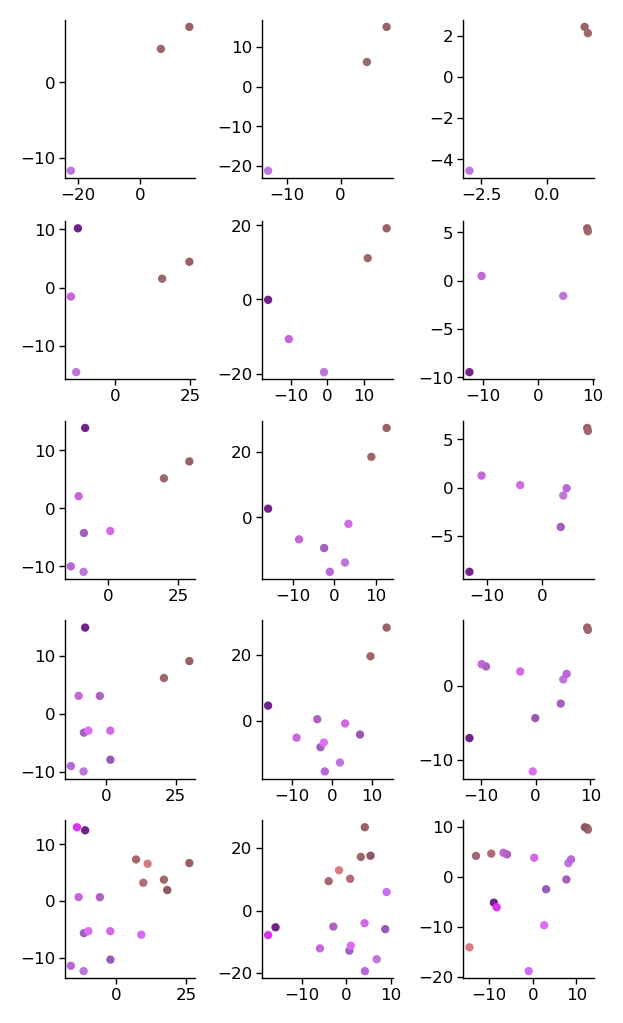

In [ ]:
#purple = 0.6???
fig, ax = plt.subplots(5,3, figsize = (3, 5))
ratio = [0.4,0.5,0.6,0.7,0.8]

for i, r in enumerate(ratio):
    num_10x_female_purple = len(cumsum_10x_female_purple[cumsum_10x_female_purple<r])
    partial_10x_female_purple = sorted_10x_female_purple[:num_10x_female_purple]
    
    colors = d_10x_female['clusterColors'][idx_purple_10x_female_fig][partial_10x_female_purple]
    ss = np.array(clusters_size_10x_female_purple)[partial_10x_female_purple]
    a = clusters_mean_10x_female_purple[partial_10x_female_purple]
    a = a - a.mean(axis=0)
    b = clusters_mean_10x[len(idx_purple_10x_fig):,:][partial_10x_female_purple]
    b = b - b.mean(axis=0)
    R_purple_test, sca = orthogonal_procrustes(a, b)
    c = (a@R_purple_test)

    ax[i,0].scatter(a[:,0], a[:,1], color = colors) #original 10x female
    ax[i,1].scatter(c[:,0], c[:,1], color = colors) #10x female after rotation
    ax[i,2].scatter(b[:,0], b[:,1], color = colors) #10x male


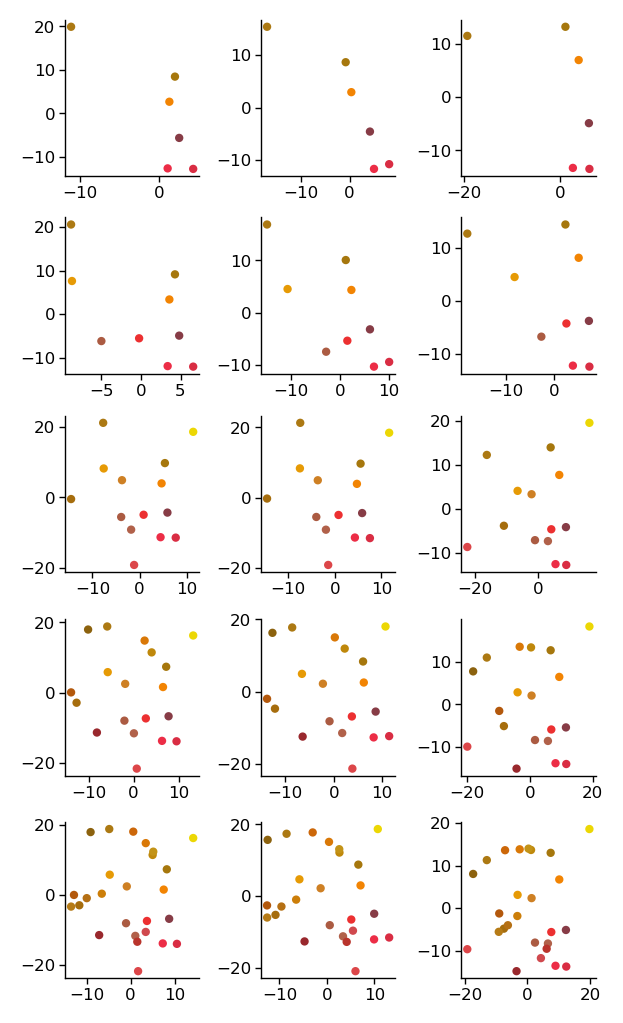

In [ ]:
#orange: no need for prucrustes?
fig, ax = plt.subplots(5,3, figsize = (3, 5))
ratio = [0.4,0.5,0.6,0.7,0.8]

for i, r in enumerate(ratio):
    num_10x_female_orange = len(cumsum_10x_female_orange[cumsum_10x_female_orange<r])
    partial_10x_female_orange = sorted_10x_female_orange[:num_10x_female_orange]
    
    colors = d_10x_female['clusterColors'][idx_orange_10x_female_fig][partial_10x_female_orange]
    ss = np.array(clusters_size_10x_female_orange)[partial_10x_female_orange]
    a = clusters_mean_10x_female_orange[partial_10x_female_orange]
    a = a - a.mean(axis=0)
    b = clusters_mean_10x[len(idx_purple_10x_fig):,:][partial_10x_female_orange]
    b = b - b.mean(axis=0)
    R_orange_test, sca = orthogonal_procrustes(a, b)
    c = (a@R_orange_test)

    ax[i,0].scatter(a[:,0], a[:,1], color = colors) #original 10x female
    ax[i,1].scatter(c[:,0], c[:,1], color = colors) #10x female after rotation
    ax[i,2].scatter(b[:,0], b[:,1], color = colors) #10x male


In [1344]:
embd_10x_female_after = embd_10x_female.copy()

In [ ]:
a = clusters_mean_10x_female_orange[partial_10x_female_orange]
a = a - a.mean(axis=0)
b = clusters_mean_10x[len(idx_purple_10x_fig):,:][partial_10x_female_orange]
b = b - b.mean(axis=0)
R_orange_test, sca = orthogonal_procrustes(a, b)
c = (a@R_orange_test)
embd_10x_female_after[mask_orange_10x_female_fig] = np.dot(embd_10x_female_after[mask_orange_10x_female_fig], R_orange_test)





In [1345]:
num_10x_female_purple = len(cumsum_10x_female_purple[cumsum_10x_female_purple<0.6])
partial_10x_female_purple = sorted_10x_female_purple[:num_10x_female_purple]

d = clusters_mean_10x_female_purple[partial_10x_female_purple]
d = d - d.mean(axis=0)
e = clusters_mean_10x[:len(idx_purple_10x_fig),:][partial_10x_female_purple]
e = e - e.mean(axis=0)
R_purple_test, sca = orthogonal_procrustes(d, e)
f = (d@R_purple_test)
embd_10x_female_after[mask_purple_10x_female_fig] = np.dot(embd_10x_female_after[mask_purple_10x_female_fig], R_purple_test)

In [1355]:
np.save(os.path.join(root_path, "embd_n_mask","embd_after_procrustes", "embd_10x_female_orange.npy"), embd_10x_female_after[mask_orange_10x_female_fig])


In [1354]:
np.save(os.path.join(root_path, "embd_n_mask", "embd_after_procrustes",  "embd_10x_female_purple.npy"), embd_10x_female_after[mask_purple_10x_female_fig])

In [1368]:
np.save(os.path.join(root_path, "embd_n_mask", "embd_after_procrustes",  "embd_10x_male_purple.npy"),  embd_10x_male[mask_purple_10x_fig])
np.save(os.path.join(root_path, "embd_n_mask", "embd_after_procrustes",  "embd_10x_male_orange.npy"),  embd_10x_male[mask_orange_10x_fig])

# plot!

(-30.0, 35.0)

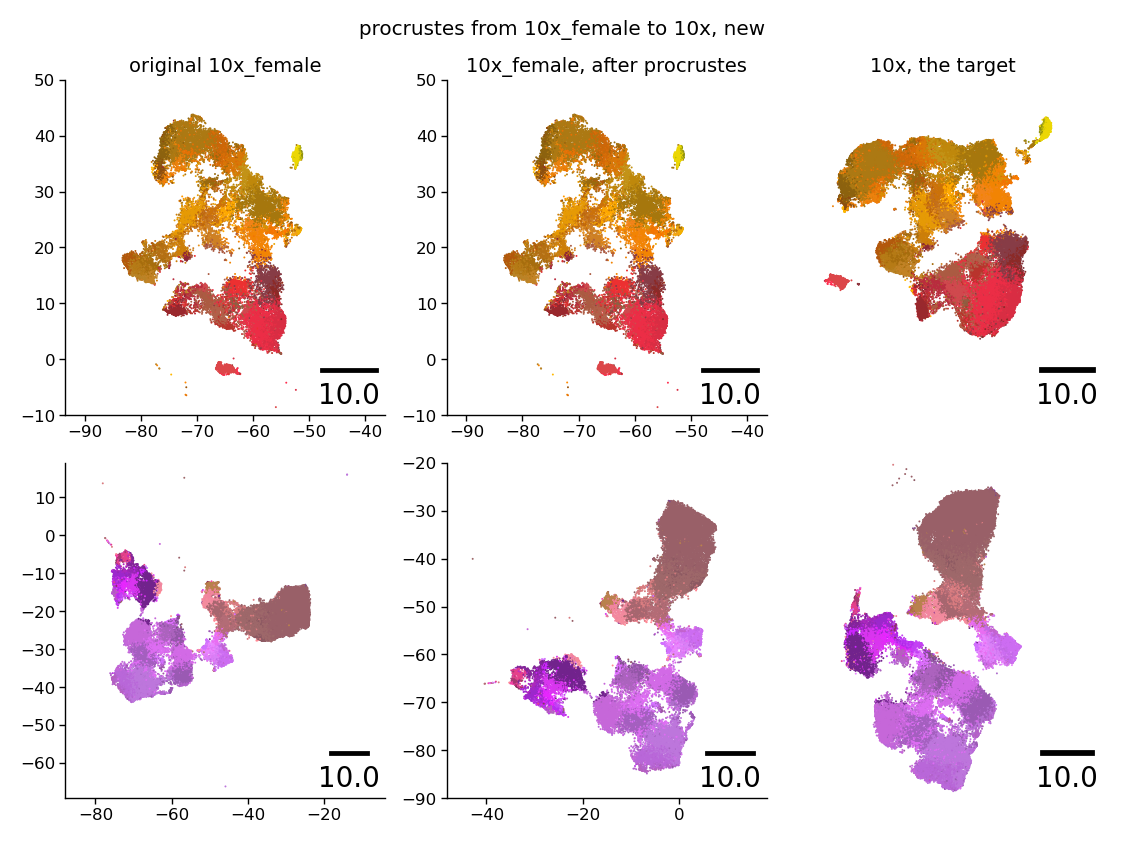

In [ ]:
fig, ax = plt.subplots(2,3)
plot_scatter(ax[0,0], embd_10x_female[mask_orange_10x_female_fig], y=d_10x_female['clusterColors'][d_10x_female['clusters']][mask_orange_10x_female_fig], s=2.0, alpha=1)
plot_scatter(ax[0,1], embd_10x_female_after[mask_orange_10x_female_fig], y=d_10x_female['clusterColors'][d_10x_female['clusters']][mask_orange_10x_female_fig], s=2.0, alpha=1)
plot_scatter(ax[0,2], embd_10x_male[mask_orange_10x_fig], y=d_10x_male['clusterColors'][d_10x_male['clusters']][mask_orange_10x_fig], s=2.0, alpha=1)

plot_scatter(ax[1,0], embd_10x_female[mask_purple_10x_female_fig], y=d_10x_female['clusterColors'][d_10x_female['clusters']][mask_purple_10x_female_fig], s=2.0, alpha=1)
plot_scatter(ax[1,1], embd_10x_female_after[mask_purple_10x_female_fig], y=d_10x_female['clusterColors'][d_10x_female['clusters']][mask_purple_10x_female_fig], s=2.0, alpha=1)
plot_scatter(ax[1,2], embd_10x_male[mask_purple_10x_fig], y=d_10x_male['clusterColors'][d_10x_male['clusters']][mask_purple_10x_fig], s=2.0, alpha=1)
ax[0,0].axis("on")
ax[0,1].axis("on")
# ax[0,2].axis("on")
ax[1,0].axis("on")
ax[1,1].axis("on")
# ax[1,2].axis("on")


fig.suptitle("procrustes from 10x_female to 10x, new")
ax[0,0].set_xlim(-90, -40)
ax[0,0].set_ylim(-10, 50)
ax[0,0].set_title("original 10x_female")
ax[0,1].set_xlim(-90, -40)
ax[0,1].set_ylim(-10, 50)
ax[0,1].set_title("10x_female, after procrustes")
ax[0,2].set_xlim(-70, -15)
ax[0,2].set_ylim(20, 70)
ax[0,2].set_title("10x, the target")

# ax[1,0].set_xlim(-80, 0)
# ax[1,0].set_ylim(-10, 80)
ax[1,1].set_xlim(-40, 10)
ax[1,1].set_ylim(-90, -20)
ax[1,2].set_xlim(-85, -45)
ax[1,2].set_ylim(-30, 35)
# fig.savefig(os.path.join(get_path("figures"), f"procrustes_10x_female.png"), dpi=300)

# save split embd_n_mask

In [1685]:
def split_embd_n_mask(some_embd, sex_color):
    n = some_embd.shape[0]
    inx = np.arange(n)

    shuffled_idx = np.copy(inx)

    np.random.seed(0)
    np.random.shuffle(shuffled_idx)

    if "male" in sex_color:
        n_splits = 10
    elif "female" in sex_color:
        n_splits = 5
    shuffled_idx = np.array_split(shuffled_idx, n_splits)
    for i in range(n_splits):
        np.save(os.path.join(root_path, "embd_n_mask","embd_after_procrustes", f"embd_10x_{sex_color}_split_{i}.npy"), some_embd[shuffled_idx[i]])

In [1364]:
split_embd_n_mask(embd_10x_female_after[mask_orange_10x_female_fig], "female_orange")

In [1365]:
split_embd_n_mask(embd_10x_female_after[mask_purple_10x_female_fig], "female_purple")

In [1689]:
split_embd_n_mask(embd_10x_male[mask_orange_10x_fig], "male_orange")

In [1690]:
split_embd_n_mask( embd_10x_male[mask_purple_10x_fig], "male_purple")